# Synthetic benchmark reproducibility: Ackley and Hartmann

This notebook reproduces the manuscript-facing synthetic benchmark summaries from the archived result matrices in `01_synthetic_functions/`. Each optimizer has 30 independent runs with a budget of 100 evaluations.

The notebook has two roles: (1) document how the raw optimization traces were generated, and (2) rebuild the final trajectories and robustness-metric table from the archived traces. Metric definitions are imported from `reproducibility/metrics.py`; they are not reimplemented here.

## Re-run the optimization experiments

Create the environments as described in [`README.md`](README.md), then run the commands below from the repository root. The runner scripts append to their output files, so use a new output directory (or remove old output files) before a fresh reproduction.

```bash
mkdir -p reproduced_results/synthetic/{ackley,hartmann}

for problem in ackley hartmann; do
  for optimizer in tidyhebo logei optuna random; do
    conda run -n tidyhebo python functions_run/${optimizer}_run.py \
      --problem ${problem} --n-repeats 30 \
      --output-file reproduced_results/synthetic/${problem}/${optimizer}_values.txt
  done

  conda run -n hebo python functions_run/hebo_run.py \
    --problem ${problem} --n-repeats 30 \
    --output-file reproduced_results/synthetic/${problem}/hebo_values.txt
done
```

The cells below intentionally analyze the archived manuscript results in `01_synthetic_functions/`. Set `RESULTS_ROOT` to the fresh directory above to analyze a new reproduction instead.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from reproducibility.metrics import calculate_metrics
from reproducibility.plotting import (
    OPTIMIZER_COLORS,
    OPTIMIZER_LABELS,
    OPTIMIZER_ORDER,
    load_values,
    plot_trajectory,
)

ROOT = Path.cwd()
RESULTS_ROOT = ROOT / "01_synthetic_functions"

SYNTHETIC_REFERENCES = {
    "ackley": {"y_best": 0.0, "y_worst": -21.57},
    "hartmann": {"y_best": 3.322368011415515, "y_worst": 0.0},
}

for task in SYNTHETIC_REFERENCES:
    for optimizer in OPTIMIZER_ORDER:
        values = load_values(RESULTS_ROOT / task, optimizer)
        assert values.shape == (30, 100), (task, optimizer, values.shape)

print("Validated 2 tasks × 5 optimizers; every matrix has shape (30, 100).")

Validated 2 tasks × 5 optimizers; every matrix has shape (30, 100).


## Optimization trajectories

Curves show the mean best-so-far objective across 30 runs; shaded regions are deterministic bootstrap 95% confidence intervals. Both test functions are represented in maximization form in the archived traces.

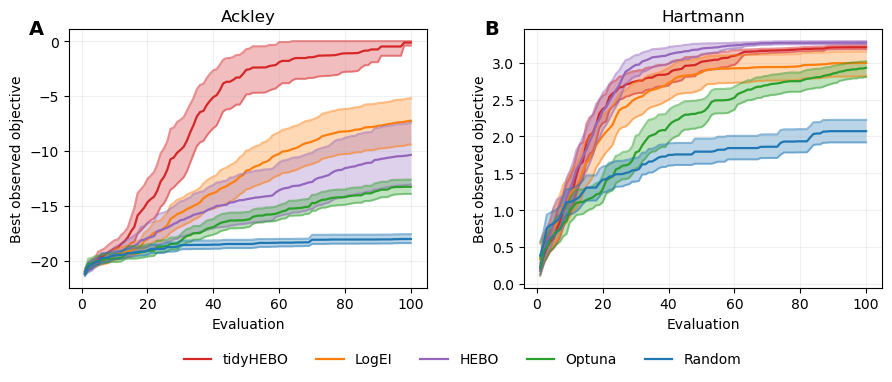

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

for ax, task, panel in zip(axes, ("ackley", "hartmann"), ("A", "B")):
    for seed, optimizer in enumerate(OPTIMIZER_ORDER):
        plot_trajectory(
            ax,
            load_values(RESULTS_ROOT / task, optimizer),
            label=OPTIMIZER_LABELS[optimizer],
            color=OPTIMIZER_COLORS[optimizer],
            seed=seed,
            ci_outline=True,
            ci_fill_alpha=0.30,
        )
    ax.set_xlabel("Evaluation")
    ax.set_ylabel("Best observed objective")
    ax.set_title(task.capitalize())
    ax.grid(alpha=0.18)
    ax.text(-0.11, 1.04, panel, transform=ax.transAxes, fontweight="bold", fontsize=14, va="top")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.subplots_adjust(bottom=0.20, wspace=0.27)
plt.show()

## Robustness metrics

Lower values are better for all three reported metrics. `median_nAUC` summarizes typical normalized-regret area, `IQR_nAUC` summarizes between-run dispersion, and `CVaR_nAUC` summarizes the upper tail of poor runs.

In [6]:
rows = []
for task, reference in SYNTHETIC_REFERENCES.items():
    for optimizer in OPTIMIZER_ORDER:
        metrics = calculate_metrics(
            load_values(RESULTS_ROOT / task, optimizer),
            reference["y_best"],
            reference["y_worst"],
        )
        rows.append({"task": task, "optimizer": OPTIMIZER_LABELS[optimizer], **metrics})

synthetic_metrics = pd.DataFrame(rows)
synthetic_metrics.round(4)

,task,optimizer,median_nAUC,IQR_nAUC,CVaR_nAUC
0,ackley,tidyHEBO,25.5223,17.9403,74.0406
1,ackley,LogEI,57.5399,29.0678,88.1178
2,ackley,HEBO,78.6919,38.4303,90.6022
3,ackley,Optuna,75.2626,6.4825,85.6048
4,ackley,Random,85.2440,5.2137,91.0526
5,hartmann,tidyHEBO,17.9824,5.7464,33.8184
6,hartmann,LogEI,20.3853,14.9614,56.6763
7,hartmann,HEBO,14.2049,6.9619,28.5483
8,hartmann,Optuna,34.4031,9.9906,55.3064
9,hartmann,Random,51.2845,13.3110,62.0908
